# Load Dataset

In [213]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statistics as st
import plotly
import plotly.express as px
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, plot, iplot
from plotly import tools

In [214]:
df_details = pd.read_csv("../datasets/IPL Ball-by-Ball 2008-2020.csv" , parse_dates=[2]) 
df_match = pd.read_csv("../datasets/IPL Matches 2008-2020.csv")

## Overview of dataset

We have two datasets from 2008 to 2020.
1. **IPL Matches:** It contains data about all the matches , It gives overview of the matches.
2. **IPL Ball to Ball:** This dataset has information about each ball in these matches.

### IPL Matches Data - Overview and Cleaning

In [215]:
df_match.shape

(816, 17)

In [216]:
df_match.describe()

,id,neutral_venue,result_margin
count,8.160000e+02,816.000000,799.000000
mean,7.563496e+05,0.094363,17.321652
std,3.058943e+05,0.292512,22.068427
min,3.359820e+05,0.000000,1.000000
25%,5.012278e+05,0.000000,6.000000
50%,7.292980e+05,0.000000,8.000000
75%,1.082626e+06,0.000000,19.500000
max,1.237181e+06,1.000000,146.000000


In [217]:
df_match.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               816 non-null    int64  
 1   city             803 non-null    object 
 2   date             816 non-null    object 
 3   player_of_match  812 non-null    object 
 4   venue            816 non-null    object 
 5   neutral_venue    816 non-null    int64  
 6   team1            816 non-null    object 
 7   team2            816 non-null    object 
 8   toss_winner      816 non-null    object 
 9   toss_decision    816 non-null    object 
 10  winner           812 non-null    object 
 11  result           812 non-null    object 
 12  result_margin    799 non-null    float64
 13  eliminator       812 non-null    object 
 14  method           19 non-null     object 
 15  umpire1          816 non-null    object 
 16  umpire2          816 non-null    object 
dtypes: float64(1), i

In [218]:
print("Null values in Matches Dataset:")
df_match.isnull().sum()

Null values in Matches Dataset:


id                   0
city                13
date                 0
player_of_match      4
venue                0
neutral_venue        0
team1                0
team2                0
toss_winner          0
toss_decision        0
winner               4
result               4
result_margin       17
eliminator           4
method             797
umpire1              0
umpire2              0
dtype: int64

In [219]:
# No of categorical and numerical columns
# Categorical Columns are more than numerical columns

num_cols = df_match.select_dtypes(exclude=['object']).columns
cat_cols = df_match.select_dtypes(include=['object']).columns

print("Numerical Columns : " , len(num_cols))
print("Categorical Columns : " , len(cat_cols))

Numerical Columns :  3
Categorical Columns :  14


In [220]:
# unique methods
df_match['method'].unique()

array([nan, 'D/L'], dtype=object)

In [221]:
# There are only two method  D/L or match is played regularly.
# I replaced NaN values with 'regular' because there is no iterruption of rain in these matches
df_match['method']=df_match['method'].fillna('Regular')

In [222]:
# fixed misabiguity right away
# fixed spelling errors in team names to make them single entity
df_match.replace('Rising Pune Supergiant','Rising Pune Supergiants', inplace=True)

In [223]:
# checking null values in city
# these matches were played in UAE as we can clearly see in venue
df_match[df_match['city'].isnull()]

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2
399,729281,NaN,2014-04-17,YS Chahal,Sharjah Cricket Stadium,1,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Royal Challengers Bangalore,wickets,8.0,N,Regular,Aleem Dar,S Ravi
402,729287,NaN,2014-04-19,PA Patel,Dubai International Cricket Stadium,1,Royal Challengers Bangalore,Mumbai Indians,Royal Challengers Bangalore,field,Royal Challengers Bangalore,wickets,7.0,N,Regular,Aleem Dar,AK Chaudhary
403,729289,NaN,2014-04-19,JP Duminy,Dubai International Cricket Stadium,1,Kolkata Knight Riders,Delhi Daredevils,Kolkata Knight Riders,bat,Delhi Daredevils,wickets,4.0,N,Regular,Aleem Dar,VA Kulkarni
404,729291,NaN,2014-04-20,GJ Maxwell,Sharjah Cricket Stadium,1,Rajasthan Royals,Kings XI Punjab,Kings XI Punjab,field,Kings XI Punjab,wickets,7.0,N,Regular,BF Bowden,M Erasmus
406,729295,NaN,2014-04-22,GJ Maxwell,Sharjah Cricket Stadium,1,Kings XI Punjab,Sunrisers Hyderabad,Sunrisers Hyderabad,field,Kings XI Punjab,runs,72.0,N,Regular,M Erasmus,S Ravi
407,729297,NaN,2014-04-23,RA Jadeja,Dubai International Cricket Stadium,1,Rajasthan Royals,Chennai Super Kings,Rajasthan Royals,field,Chennai Super Kings,runs,7.0,N,Regular,HDPK Dharmasena,RK Illingworth
408,729299,NaN,2014-04-24,CA Lynn,Sharjah Cricket Stadium,1,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,2.0,N,Regular,Aleem Dar,VA Kulkarni
409,729301,NaN,2014-04-25,AJ Finch,Dubai International Cricket Stadium,1,Sunrisers Hyderabad,Delhi Daredevils,Sunrisers Hyderabad,bat,Sunrisers Hyderabad,runs,4.0,N,Regular,M Erasmus,S Ravi
410,729303,NaN,2014-04-25,MM Sharma,Dubai International Cricket Stadium,1,Chennai Super Kings,Mumbai Indians,Mumbai Indians,bat,Chennai Super Kings,wickets,7.0,N,Regular,BF Bowden,M Erasmus
413,729309,NaN,2014-04-27,M Vijay,Sharjah Cricket Stadium,1,Delhi Daredevils,Mumbai Indians,Mumbai Indians,bat,Delhi Daredevils,wickets,6.0,N,Regular,Aleem Dar,VA Kulkarni


In [224]:
data = np.array(df_match)
venues = set(data[: , 4])
city = set(data[: , 1])

In [225]:
# filling missing values in city column
# match[1] != match[1] is used to check null values because np.isnan does not work on string values

for match in data:
    if match[1] != match[1] and match[4] == 'Dubai International Cricket Stadium':
        match[1] = 'Dubai'
    elif match[1] != match[1] and match[4] == 'Sharjah Cricket Stadium':
        match[1] = 'Sharjah'


In [226]:
# filling missing values in result margin 
# filled values 0 because these matches were ties

for match in data:
    if match[12] != match[12] and match[11] == 'tie':
        match[12] = float(0)

In [227]:
df_match = pd.DataFrame(data , columns=['id', 'city', 'date', 'player_of_match', 'venue', 'neutral_venue',
       'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result',
       'result_margin', 'eliminator', 'method', 'umpire1', 'umpire2'] )

In [228]:
# dropped cancelled matches
df_match = df_match.dropna()

In [229]:
df_match.shape

(812, 17)

In [230]:
# No missing values in the dataset now
print(df_match.isnull().sum())

id                 0
city               0
date               0
player_of_match    0
venue              0
neutral_venue      0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
result             0
result_margin      0
eliminator         0
method             0
umpire1            0
umpire2            0
dtype: int64


### IPL Ball by Ball data - overview and cleaning

In [231]:
df_details.shape

(193468, 18)

In [232]:
df_details.describe()

,id,inning,ball,batsman_runs,extra_runs,total_runs,non_boundary,is_wicket
count,1.934680e+05,193468.000000,193468.000000,193468.000000,193468.000000,193468.000000,193468.000000,193468.000000
mean,7.567688e+05,1.482131,3.615967,1.240231,0.066414,1.306645,0.000083,0.049078
std,3.060971e+05,0.499682,1.807128,1.610867,0.339991,1.598802,0.009094,0.216031
min,3.359820e+05,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.012270e+05,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.292970e+05,1.000000,4.000000,1.000000,0.000000,1.000000,0.000000,0.000000
75%,1.082628e+06,2.000000,5.000000,1.000000,0.000000,1.000000,0.000000,0.000000
max,1.237181e+06,2.000000,9.000000,6.000000,7.000000,7.000000,1.000000,1.000000


In [233]:
# checking datatypes and misisng columns
df_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193468 entries, 0 to 193467
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   id                193468 non-null  int64 
 1   inning            193468 non-null  int64 
 2   over              193468 non-null  object
 3   ball              193468 non-null  int64 
 4   batsman           193468 non-null  object
 5   non_striker       193468 non-null  object
 6   bowler            193468 non-null  object
 7   batsman_runs      193468 non-null  int64 
 8   extra_runs        193468 non-null  int64 
 9   total_runs        193468 non-null  int64 
 10  non_boundary      193468 non-null  int64 
 11  is_wicket         193468 non-null  int64 
 12  dismissal_kind    9495 non-null    object
 13  player_dismissed  9495 non-null    object
 14  fielder           6784 non-null    object
 15  extras_type       10233 non-null   object
 16  batting_team      193468 non-null  obj

In [234]:
# checking missing values
df_details.isnull().sum()

id                       0
inning                   0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
batsman_runs             0
extra_runs               0
total_runs               0
non_boundary             0
is_wicket                0
dismissal_kind      183973
player_dismissed    183973
fielder             186684
extras_type         183235
batting_team             0
bowling_team           191
dtype: int64

In [235]:
# picking up a random id from the dataset to check if the id's match from both datsets
df_match[df_match['id'] == 335982]

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2
0,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,Regular,Asad Rauf,RE Koertzen


In [236]:
df_details[df_details['id'] == 335982].head()

,id,inning,over,ball,batsman,non_striker,bowler,batsman_runs,extra_runs,total_runs,non_boundary,is_wicket,dismissal_kind,player_dismissed,fielder,extras_type,batting_team,bowling_team
0,335982,1,6,5,RT Ponting,BB McCullum,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
1,335982,1,6,6,BB McCullum,RT Ponting,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
2,335982,1,7,1,BB McCullum,RT Ponting,Z Khan,0,0,0,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
3,335982,1,7,2,BB McCullum,RT Ponting,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
4,335982,1,7,3,RT Ponting,BB McCullum,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore


In [237]:
# type of dismissal mentioned in dataset
# nan means player is not out
print(df_details['dismissal_kind'].unique())

[nan 'caught' 'run out' 'bowled' 'lbw' 'retired hurt' 'stumped'
 'caught and bowled' 'hit wicket' 'obstructing the field']


In [238]:
# type of extras
# In this columns nan means the run was not extra it was scored by the batter
print(df_details['extras_type'].unique())

[nan 'byes' 'wides' 'legbyes' 'noballs' 'penalty']


In [239]:
# checking for null values in bowling team
df = df_details[df_details['bowling_team'].isnull()]
df.head()

,id,inning,over,ball,batsman,non_striker,bowler,batsman_runs,extra_runs,total_runs,non_boundary,is_wicket,dismissal_kind,player_dismissed,fielder,extras_type,batting_team,bowling_team
57048,501265,1,0,1,NV Ojha,DA Warner,AC Thomas,1,0,1,0,0,NaN,NaN,NaN,NaN,Delhi Daredevils,NaN
57049,501265,1,0,2,DA Warner,NV Ojha,AC Thomas,0,1,1,0,0,NaN,NaN,NaN,legbyes,Delhi Daredevils,NaN
57050,501265,1,1,1,DA Warner,NV Ojha,JP Faulkner,0,1,1,0,0,NaN,NaN,NaN,legbyes,Delhi Daredevils,NaN
57051,501265,1,1,2,NV Ojha,DA Warner,JP Faulkner,0,0,0,0,0,NaN,NaN,NaN,NaN,Delhi Daredevils,NaN
57052,501265,1,1,3,NV Ojha,DA Warner,JP Faulkner,0,0,0,0,0,NaN,NaN,NaN,NaN,Delhi Daredevils,NaN


In [240]:
df['id'].unique()

array([501265, 829763], dtype=int64)

In [241]:
# these two matches are deleted that means these matches were suspended
501265 in df_match['id'].unique() , 829763 in df_match['id'].unique() 

(False, False)

In [242]:
# filled missing values
df_details['dismissal_kind'] = df_details['dismissal_kind'].fillna('not out')
df_details['player_dismissed'] = df_details['player_dismissed'].fillna('none')
df_details['fielder'] = df_details['fielder'].fillna('unknown')
df_details['extras_type'] = df_details['extras_type'].fillna('no extra')
# df_details = df_details.dropna()

In [243]:
print(df_details[df_details['bowling_team'].isnull()]['id'].unique())

[501265 829763]


In [244]:
# checking for matches that are not in the match dataset bu present in ball to ball dataset
# the reason could be suspension of the matches
lst = []
for match in df_details['id'].unique():
    if match not in list(df_match['id']):
        lst.append(match)

lst

[501265, 829763, 829813, 1178424]

In [245]:
# dropping these values from ball to ball dataset
df_details.drop(df_details[df_details['id'].isin(lst)].index , inplace = True)

In [246]:
len(df_details['id'].unique())

812

## Finding Insights 

### Questions to answer
---
- Matches affected by rain.
- What was the count of matches played in each season?
- How many runs were scored in each season?
- What were the runs scored per match in different seasons?
- Who has umpired the most?
- Which team has won the most tosses?
- What does the team decide after winning the toss?
- How does the toss decision vary across seasons?
- Does winning the toss imply winning the game?
- How many times has the chasing team won the match?
- Which all teams had won this tournament?
- Which team has played the most number of matches?
- Which team has won the most number of times?
- Which team has the highest winning percentage?
- Is there any lucky venue for a particular team?
- Innings wise comparison between teams
- Which team has scored the most number of 200+ scores?
- Which team has conceded 200+ scores the most?
- What was the highest run scored by a team in a single match?
- Which is the biggest win in terms of run margin?
- Which batsmen have played the most number of balls?
- Who are the leading run-scorers of all time?
- Who has hit the most number of 4's?
- Who has hit the most number of 6's?
- Who has the highest strike rate?
- Who is the leading wicket-taker?
- Which stadium has hosted the most number of matches?

### Match Analysis

#### Matches affected by rain

In [247]:
print("🌧️ number of matches affected by rain ", df_match[df_match['method'] == 'D/L'].shape[0])

🌧️ number of matches affected by rain  19


#### What was the count of matches played in each season?

In [248]:
df_match['date'] = pd.to_datetime(df_match['date'] , format="%Y-%m-%d")
df_match['season'] = df_match['date'].dt.year

df = df_match.groupby('season').count()
df.rename(columns={'id':'matches'} , inplace = True)

matches_per_season = dict(df['matches'])

print("Matches per season (2008 - 2020)")

print("-"*32)
for i in matches_per_season :
    print(i, ":" , matches_per_season[i] )
print("-"*32)

Matches per season (2008 - 2020)
--------------------------------
2008 : 58
2009 : 57
2010 : 60
2011 : 72
2012 : 74
2013 : 76
2014 : 60
2015 : 57
2016 : 60
2017 : 59
2018 : 60
2019 : 59
2020 : 60
--------------------------------


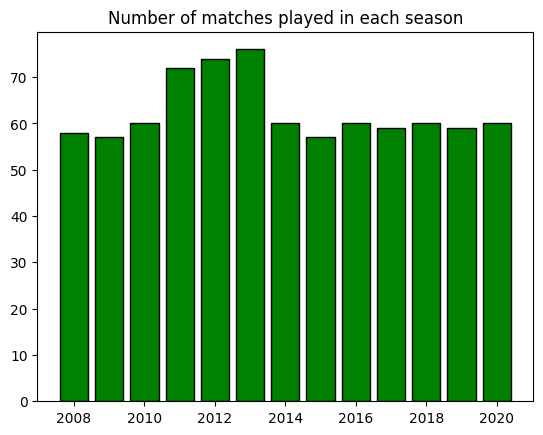

In [249]:
plt.title("Number of matches played in each season")
plt.bar(x = matches_per_season.keys() , height = matches_per_season.values() ,color = 'green' , edgecolor = 'black' )
plt.show()

📌 In year 2011 , BCCI introduced 2 more franchises that indirectly increases number matches although these teams were terminated after 2013 that's why we can see decrease in runs scored.

#### How many runs were scored in each season?

In [250]:
df = df_details.groupby(['id', 'inning']).sum()

first_inning = []
second_inning = []

runs = dict(df['total_runs'])
for i in dict(df['total_runs']).keys():
    if i[1] == 1:
        first_inning.append(runs[i])
    else:
        second_inning.append(runs[i])
        

C:\Users\windows\AppData\Local\Temp\ipykernel_10872\1769873066.py:1: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.



In [251]:
df_match['first_inning_runs'] = first_inning
df_match['second_inning_runs'] = second_inning
df_match['total_runs'] = df_match['first_inning_runs'] + df_match['second_inning_runs']

In [252]:
df = df_match[['season' , 'total_runs']]
print("Runs scored each season (2008 -2020)")
print("-"*30)
df = df.groupby('season').sum().reset_index()
df.style.hide()



Runs scored each season (2008 -2020)
------------------------------


season,total_runs
2008,17937
2009,16320
2010,18864
2011,21098
2012,22453
2013,22541
2014,18909
2015,17943
2016,18862
2017,18769


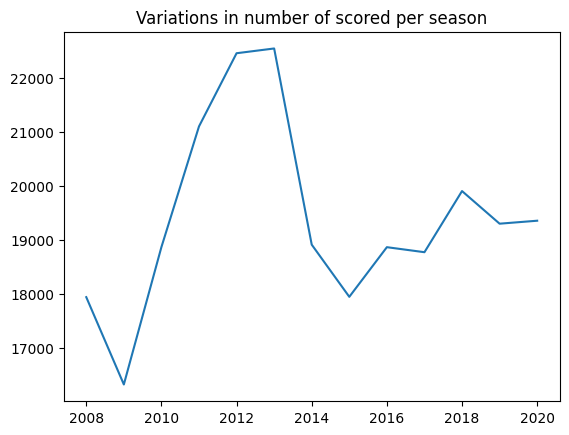

In [253]:
plt.plot(df.season , df.total_runs)
plt.title("Variations in number of scored per season")
plt.show()

📈 Most runs were scored in 2013 season , having 22541 runs scored in a single season, 2011 and 2012 season are also among the high scoring seasons crossing 20k runs marks.

#### Runs scored per match in each season 

In [254]:
df = df_match[['season','total_runs']].groupby('season').mean().reset_index()
df.rename(columns = {'total_runs':'average_runs'} , inplace = True)
df.style.hide()

season,average_runs
2008,309.258621
2009,286.315789
2010,314.400000
2011,293.027778
2012,303.418919
2013,296.592105
2014,315.150000
2015,314.789474
2016,314.366667
2017,318.118644


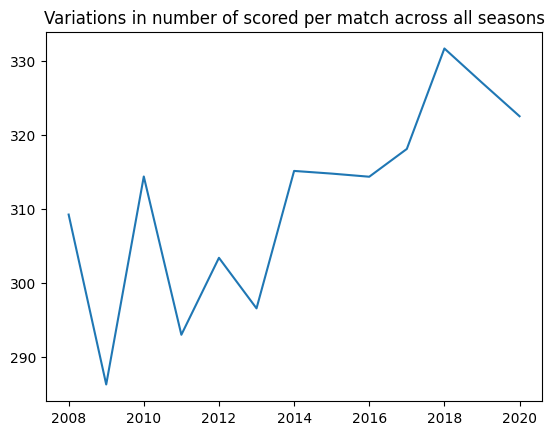

In [255]:
plt.plot(df.season , df.average_runs)
plt.title("Variations in number of scored per match across all seasons")
plt.show()

📌 Number of runs scored per match is comparatively higher in 2017 to 2020.

#### Who has umpired the most?

In [256]:
# find unique umpires
umpires = list(df_match['umpire1'])

for umpire in list(df_match['umpire2']):
    umpires.append(umpire)
    
umpires = list(set(umpires))

In [257]:
# count number of matches for each umpire
lst = []

for umpire in umpires:
    c = 0
    for i in range(len(df_match[['umpire1','umpire2']])): 
        
        if umpire in df_match[['umpire1','umpire2']].values[i]:
            c+=1

    lst.append([umpire, c])

In [258]:
pd.DataFrame(lst , columns=['Umpire' , 'No of Matches']).sort_values(by = 'No of Matches' , ascending=False).head(10).style.hide()

Umpire,No of Matches
S Ravi,121
HDPK Dharmasena,93
AK Chaudhary,87
C Shamshuddin,82
M Erasmus,65
CK Nandan,57
Nitin Menon,57
SJA Taufel,55
Asad Rauf,51
VA Kulkarni,50


☝️S Ravi have umpired the most number of matches.

#### Which team has won the most tosses?

In [259]:
df_match['toss_winner'].value_counts()

Mumbai Indians                 106
Kolkata Knight Riders           98
Chennai Super Kings             97
Royal Challengers Bangalore     86
Rajasthan Royals                85
Kings XI Punjab                 85
Delhi Daredevils                79
Sunrisers Hyderabad             57
Deccan Chargers                 43
Pune Warriors                   20
Delhi Capitals                  20
Gujarat Lions                   15
Rising Pune Supergiants         13
Kochi Tuskers Kerala             8
Name: toss_winner, dtype: int64

In [260]:
toss_wins = df_match['toss_winner'].value_counts().to_dict()

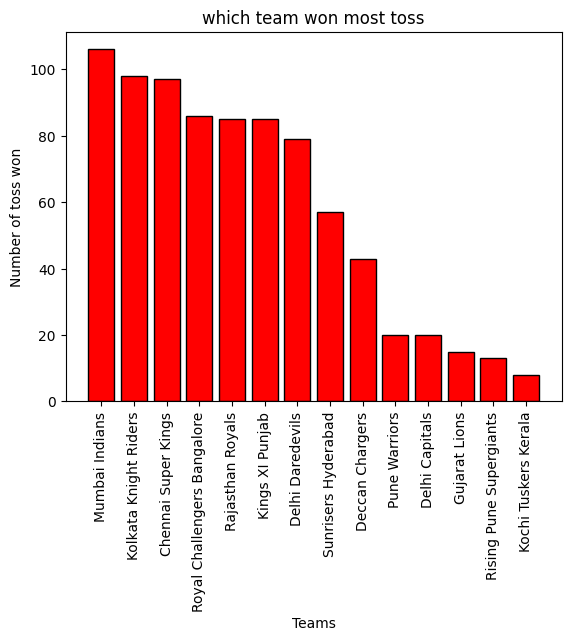

In [261]:
plt.title("which team won most toss")
plt.xlabel('Teams')
plt.ylabel('Number of toss won')
plt.bar(toss_wins.keys()  ,toss_wins.values()  ,
    color = "red" , edgecolor = 'black' )
plt.xticks(rotation=90)

plt.show()

🤌 <b>Mumbai Indians</b> won most number of tosses.

#### What does the team decide after winnig the toss ?

In [262]:
df_match['toss_decision'].mode()[0]

'field'

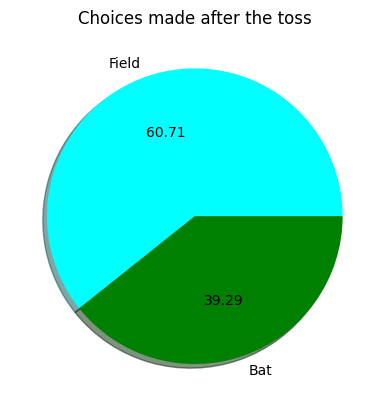

In [263]:
plt.title("Choices made after the toss")

# plt.bar(df_match['toss_decision'].unique()   , list(df_match['toss_decision'].value_counts() , ) ,
#     color = "red" , edgecolor = 'black' , tick_label = ['field' , 'bat'])
plt.pie(x = list(df_match['toss_decision'].value_counts())  , labels = ['Field' , 'Bat'] ,
        colors=[ 'Cyan' , 'Green'],
       shadow=True ,
        autopct='%.2f'
        
       )
plt.show()

In [264]:
df_match['toss_decision'].value_counts()

field    493
bat      319
Name: toss_decision, dtype: int64

⚾majority of teams chose to <b>field</b> first after winnig the toss


#### Variations in toss decisions across the seasons

In [265]:
df_vals = df_match[['season' , 'toss_decision']].values

dic = {}
for s in df_match['season'].unique():
    lst = []
    for values in df_vals:
        if values[0] == s:
            lst.append(values[1])
    dic[s] = lst



In [266]:
print("Choices made across all the seasons")
print("-"*30)
for s in df_match['season'].unique():
    print(s ,':', st.mode(dic[s]))
print("-"*30)


Choices made across all the seasons
------------------------------
2008 : field
2009 : bat
2010 : bat
2011 : field
2012 : field
2013 : bat
2014 : field
2015 : field
2016 : field
2017 : field
2018 : field
2019 : field
2020 : field
------------------------------


In [267]:
np.unique(dic[s] , return_counts=True )[1]

array([27, 33], dtype=int64)

In [268]:
temp  = [] 
seasons = dic.keys()

for s in seasons:
    temp.append([s , np.unique(dic[s] , return_counts=True )[1][0] , np.unique(dic[s] , return_counts=True )[1][1] ])

In [269]:
df = pd.DataFrame(data=temp , columns=['seasons' , 'bat' , 'field'])

In [270]:
df

,seasons,bat,field
0,2008,26,32
1,2009,35,22
2,2010,39,21
3,2011,24,48
4,2012,37,37
5,2013,45,31
6,2014,19,41
7,2015,25,32
8,2016,11,49
9,2017,11,48


In [271]:

px.histogram(data_frame=df_match,x='season',color='toss_decision',barmode='group')

 📍We can see that in majority of seasons teams chose field first after winning the toss.

#### Does winning the toss imply winning the game

In [272]:
df = df_match[['team1', 'team2','toss_winner','toss_decision', 'winner']]

In [273]:
toss_winners = list(df_match['toss_winner'])
match_winner = list(df_match['winner'])

c = 0
for team in range(len(toss_winners)):
    
    if toss_winners[team] == match_winner[team]:
        c+=1

total_matches = len(match_winner)

ratio = (c/total_matches)*100

print("total matches played :",total_matches )
print("number of times toss winner and match winner is same :",c)
print("percentage :",ratio)

total matches played : 812
number of times toss winner and match winner is same : 418
percentage : 51.47783251231527


In [274]:
# added new column to the table
lst = []
for i in range(len(df)):
    if df.iloc[i]['toss_winner'] == df.iloc[i]['winner']:
        lst.append('Yes') 
    else:
        lst.append('No')

df['toss_to_win'] = lst
df

C:\Users\windows\AppData\Local\Temp\ipykernel_10872\2352953888.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,team1,team2,toss_winner,toss_decision,winner,toss_to_win
0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,No
1,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,Yes
2,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,No
3,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,No
4,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,No
...,...,...,...,...,...,...
811,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,Royal Challengers Bangalore,No
812,Mumbai Indians,Delhi Capitals,Delhi Capitals,field,Mumbai Indians,No
813,Royal Challengers Bangalore,Sunrisers Hyderabad,Sunrisers Hyderabad,field,Sunrisers Hyderabad,Yes
814,Delhi Capitals,Sunrisers Hyderabad,Delhi Capitals,bat,Delhi Capitals,Yes


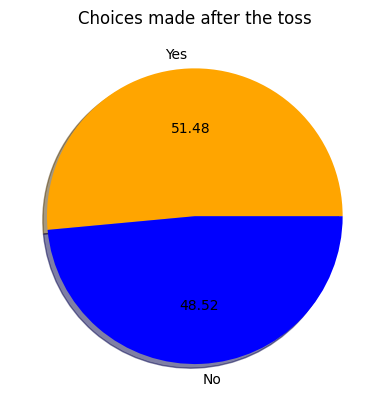

In [275]:
plt.title("Choices made after the toss")

plt.pie(x = list(df['toss_to_win'].value_counts())  , labels = ['Yes' , 'No'] ,
        colors=[ 'orange' , 'Blue'],
       shadow=True ,
        autopct='%.2f'
    
       )
plt.show()

👉In IPL 812 matched are played in total in which 418 times match winnig team won the toss , that is 51% of matches of total matches played. So we can say that winning the toss favours the team, but T20 cricket is very dynamic game that's why these numbers are not very high.

#### how many times chasing team wins the match ?

When a chasing team wins the game the result is decided by the wickets. We will use attribute to answer this questions

In [276]:
chasers = df_match[df_match['result'] == 'wickets'].shape[0]

print("number of times chasing teams won: " , chasers)

ratio = (chasers/total_matches)*100

print("ratio chasing teams won to total matches: ", ratio)

number of times chasing teams won:  435
ratio chasing teams won to total matches:  53.57142857142857


📌 We can see 53 times of 100 chasing team wins the match.

### Team Analysis

#### Which all teams have won this tournament before


In [277]:
df_match[df_match['eliminator'] == 'Y']['winner'].unique()

array(['Rajasthan Royals', 'Kings XI Punjab', 'Sunrisers Hyderabad',
       'Royal Challengers Bangalore', 'Mumbai Indians', 'Delhi Capitals',
       'Kolkata Knight Riders'], dtype=object)

In [278]:
seasons = df_match['season'].unique()

print("IPL Champions form 2008 - 2020")
print("-"*30)

for s in seasons:
    champions = df_match[df_match['season'] == s].values[-1][10]
    print(s,' - ',champions)
    
print("-"*30)

IPL Champions form 2008 - 2020
------------------------------
2008  -  Rajasthan Royals
2009  -  Deccan Chargers
2010  -  Chennai Super Kings
2011  -  Chennai Super Kings
2012  -  Kolkata Knight Riders
2013  -  Mumbai Indians
2014  -  Kolkata Knight Riders
2015  -  Mumbai Indians
2016  -  Sunrisers Hyderabad
2017  -  Mumbai Indians
2018  -  Chennai Super Kings
2019  -  Mumbai Indians
2020  -  Mumbai Indians
------------------------------


📌 Mumbai Indians is most successful team winnig most number of titles in 2013,2015,2017,2019,2020 seasons respectively.

### Which team has won most number of times? 

In [279]:
team_ser = df_match.groupby('winner').count()
team_ser = team_ser['team1'].sort_values(ascending=False)
print("Top 5 teams with most number of wins")
print("-"*40)
team_ser.head()

Top 5 teams with most number of wins
----------------------------------------


winner
Mumbai Indians                 120
Chennai Super Kings            106
Kolkata Knight Riders           99
Royal Challengers Bangalore     91
Kings XI Punjab                 88
Name: team1, dtype: int64

In [280]:
# creating new data frame for future use
df_teams = pd.DataFrame(data=team_ser , index=team_ser.index)
df_teams.reset_index(inplace=True)
df_teams

,winner,team1
0,Mumbai Indians,120
1,Chennai Super Kings,106
2,Kolkata Knight Riders,99
3,Royal Challengers Bangalore,91
4,Kings XI Punjab,88
5,Rajasthan Royals,81
6,Delhi Daredevils,67
7,Sunrisers Hyderabad,66
8,Deccan Chargers,29
9,Delhi Capitals,19


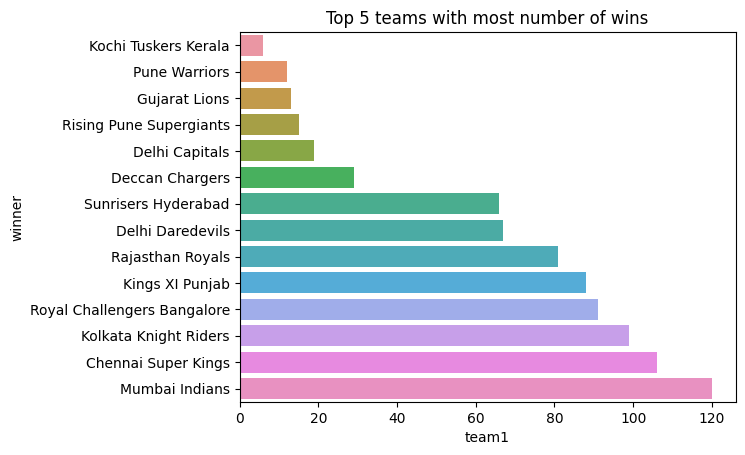

In [281]:
temp_df = df_teams.sort_values(by = 'team1')

plt.title("Top 5 teams with most number of wins")

plt.ylabel("Team names")
plt.xlabel("Number of macthes won")


sns.barplot(data = temp_df,y = temp_df['winner'],x = temp_df['team1'] ,orient = 'h')
plt.show()

#### Which team has most number of matches? 


In [282]:
ser = df_match['team1'].value_counts().sort_index() + df_match['team2'].value_counts().sort_index()

df = pd.DataFrame(data = ser, index = ser.index).reset_index()
df.rename(columns={'index':'teams', 0:'count'} , inplace = True )
print("Top 5 teams having most number of matches")

temp_df = df.sort_values(by = 'count', ascending=False)
temp_df.head().style.hide()


Top 5 teams having most number of matches


teams,count
Mumbai Indians,203
Kolkata Knight Riders,192
Royal Challengers Bangalore,192
Kings XI Punjab,190
Chennai Super Kings,178


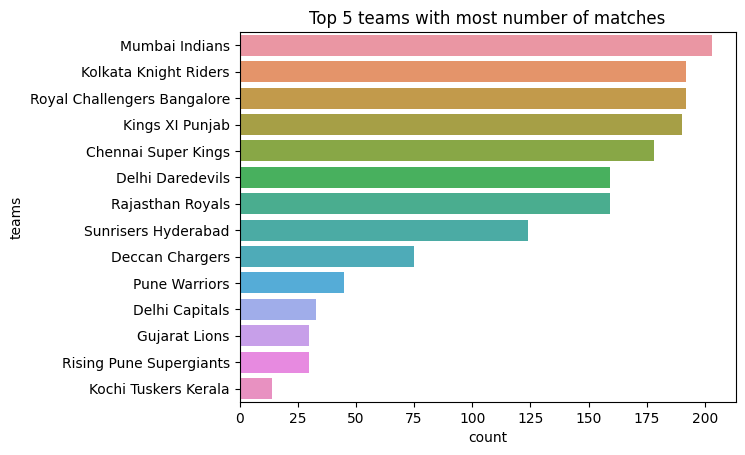

In [283]:

plt.title("Top 5 teams with most number of matches")

plt.ylabel("Team names")
plt.xlabel("Number of macthes played")

# plt.barh(temp_df['team1'] , temp_df['count'])
sns.barplot(data=temp_df , x = 'count' , y = 'teams' , orient='h')
plt.show()

#### Highest match winning percentage 

In [284]:
# sorting values of df_teams to order it same way as df
df_teams.sort_values(by = 'winner' , inplace=True) # no of wins
temp_df = temp_df.sort_values(by='teams')      # no of matches

In [285]:
temp_df['wins'] = list(df_teams['team1'].values)

In [286]:
df_teams = temp_df
df_teams.rename(columns = {'team1':'teams' , 'count':'matches'} , inplace= True)
df_teams

,teams,matches,wins
0,Chennai Super Kings,178,106
1,Deccan Chargers,75,29
2,Delhi Capitals,33,19
3,Delhi Daredevils,159,67
4,Gujarat Lions,30,13
5,Kings XI Punjab,190,88
6,Kochi Tuskers Kerala,14,6
7,Kolkata Knight Riders,192,99
8,Mumbai Indians,203,120
9,Pune Warriors,45,12


In [287]:
# claculate match winning percentage 

df_teams['win_perc'] = (df_teams['wins']/df_teams['matches'] )*100

print("top 5 teams with highest winnig percentage")
df_teams.sort_values(by = 'win_perc' , ascending=False).head().style.hide()

top 5 teams with highest winnig percentage


teams,matches,wins,win_perc
Chennai Super Kings,178,106,59.550562
Mumbai Indians,203,120,59.113300
Delhi Capitals,33,19,57.575758
Sunrisers Hyderabad,124,66,53.225806
Kolkata Knight Riders,192,99,51.562500


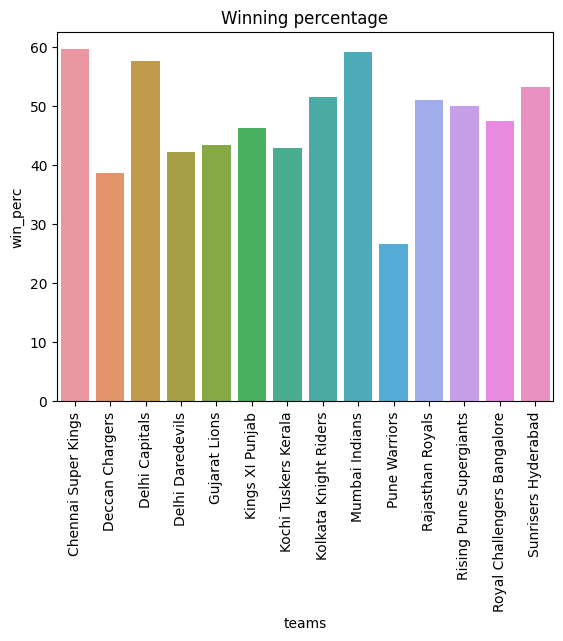

In [288]:
plt.title("Winning percentage")
sns.barplot(data = df_teams , x = 'teams' ,y = 'win_perc' )
plt.xticks(rotation = 90)
plt.show()

📈 Chennai Super kings have slightly higher winnig percentage than Mumbai Indians both have won 59% of there matches

### is there any lucky venue for any team ?

In [289]:
venues = list(set(df_match['venue']))

df_match[df_match['venue'] == venues[1]]['team1'].value_counts()
# df_match[df_match['venue'] == '']



Royal Challengers Bangalore    4
Kings XI Punjab                3
Chennai Super Kings            3
Deccan Chargers                2
Delhi Daredevils               1
Mumbai Indians                 1
Kolkata Knight Riders          1
Name: team1, dtype: int64

#### Which team scored most 200s

In [290]:
lst = []
for i in df_details['id'].unique():
    teams = []
    for team in df_details[df_details['id'] == i]['batting_team'].unique():
        teams.append(team)
        if len(teams) == 2:
            second_inning = df_details[(df_details['id'] == i) & (df_details['batting_team'] == teams[1])]['total_runs'].sum()
        else:
            first_inning = df_details[(df_details['id'] == i) & (df_details['batting_team'] == teams[0])]['total_runs'].sum()
        
    lst.append([i,teams[0],first_inning , teams[1] , second_inning])

In [291]:
df_runs_scored = pd.DataFrame(lst , columns=['id','team1','team1_runs','team2','team2_runs'])

In [292]:
# teams 1 scored
ser1 = df_runs_scored[(df_runs_scored['team1_runs' ]>=200)  ]['team1'].value_counts().sort_index()
# team 2 scored
ser2 = df_runs_scored[(df_runs_scored['team2_runs' ]>=200)  ]['team2'].value_counts().sort_index()
#total
ser3 = ser1 + ser2

In [293]:
ser3['Deccan Chargers'] = 1
ser3['Gujarat Lions'] = 1

In [294]:
print("Number of times teams have scored 200+ runs")
ser3.sort_values(ascending=False)

Number of times teams have scored 200+ runs


Royal Challengers Bangalore    18.0
Chennai Super Kings            17.0
Kings XI Punjab                14.0
Mumbai Indians                 14.0
Kolkata Knight Riders          12.0
Sunrisers Hyderabad            12.0
Rajasthan Royals                9.0
Delhi Daredevils                5.0
Delhi Capitals                  2.0
Deccan Chargers                 1.0
Gujarat Lions                   1.0
dtype: float64

In [295]:
df = pd.DataFrame(data = ser3)

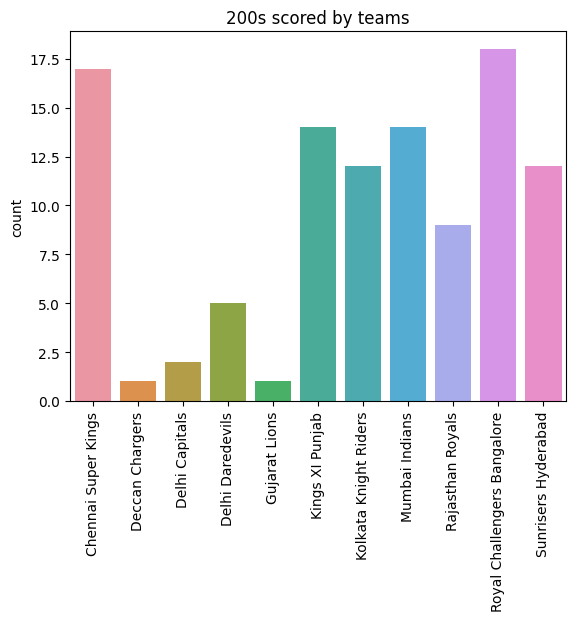

In [296]:
plt.title("200s scored by teams")
df.rename(columns={0:'count'}, inplace=True)

sns.barplot(data=df , x = df.index , y = df['count'])
plt.xticks(rotation = 90)
plt.show()

📌 Royal Challengers banglore have scored most number of 200+ runs oi.e 18 times.

#### Which team conceded 200+ runs most number of times ?

In [297]:
df_runs_scored

,id,team1,team1_runs,team2,team2_runs
0,335982,Kolkata Knight Riders,222,Royal Challengers Bangalore,82
1,335983,Kings XI Punjab,207,Chennai Super Kings,240
2,335984,Rajasthan Royals,129,Delhi Daredevils,132
3,335985,Mumbai Indians,165,Royal Challengers Bangalore,166
4,335986,Kolkata Knight Riders,112,Deccan Chargers,110
...,...,...,...,...,...
807,1216547,Royal Challengers Bangalore,201,Mumbai Indians,201
808,1237177,Delhi Capitals,143,Mumbai Indians,200
809,1237178,Royal Challengers Bangalore,131,Sunrisers Hyderabad,132
810,1237180,Delhi Capitals,189,Sunrisers Hyderabad,172


In [298]:
runs_conc = df_runs_scored

In [299]:
team1_conc = df_runs_scored['team2_runs'].values
team2_conc = df_runs_scored['team1_runs'].values
runs_conc['team1_runs'] = team1_conc
runs_conc['team2_runs'] = team2_conc


In [300]:
# teams 1 concede
ser1 = runs_conc[(runs_conc['team1_runs' ]>=200)  ]['team1'].value_counts().sort_index()
# team 2 scored
ser2 = runs_conc[(runs_conc['team2_runs' ]>=200)  ]['team2'].value_counts().sort_index()
#total
ser3 = ser1 + ser2

In [301]:
ser3

Chennai Super Kings            12.0
Deccan Chargers                 NaN
Delhi Capitals                  3.0
Delhi Daredevils               11.0
Gujarat Lions                   3.0
Kings XI Punjab                20.0
Kolkata Knight Riders          10.0
Mumbai Indians                  8.0
Pune Warriors                   NaN
Rajasthan Royals               10.0
Rising Pune Supergiant          NaN
Royal Challengers Bangalore    17.0
Sunrisers Hyderabad             7.0
dtype: float64

In [302]:
# filling missing values manually
ser3['Deccan Chargers'] = 2
ser3['Pune Warriors'] = 1
ser3['Rising Pune Supergiant'] = 1

In [303]:
print("Teams who concede 200+ runs most")
ser3.sort_values(ascending=False)

Teams who concede 200+ runs most


Kings XI Punjab                20.0
Royal Challengers Bangalore    17.0
Chennai Super Kings            12.0
Delhi Daredevils               11.0
Kolkata Knight Riders          10.0
Rajasthan Royals               10.0
Mumbai Indians                  8.0
Sunrisers Hyderabad             7.0
Delhi Capitals                  3.0
Gujarat Lions                   3.0
Deccan Chargers                 2.0
Pune Warriors                   1.0
Rising Pune Supergiant          1.0
dtype: float64

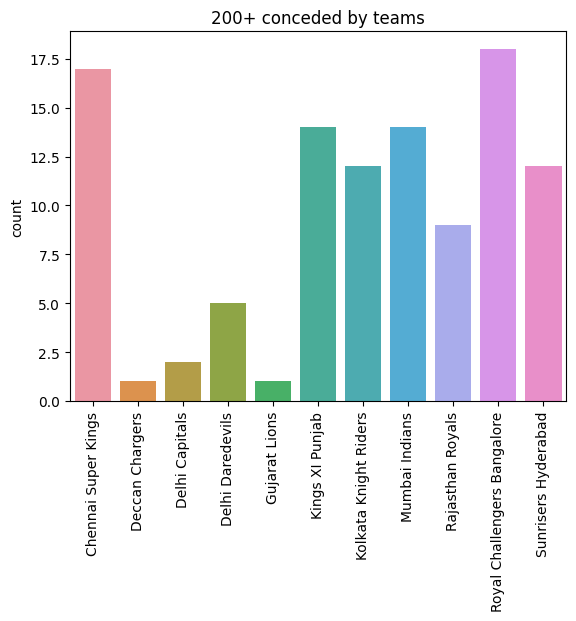

In [304]:
plt.title("200+ conceded by teams")
sns.barplot(data=df , x = df.index , y = df['count'])
plt.xticks(rotation = 90)
plt.show()

📌 KXIP has concede most number of 200+ scores in IPL

#### What was the highest run scored in a single match ?

In [305]:
df_match[df_match['first_inning_runs'] == df_match['first_inning_runs'].max()  ]

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,...,result,result_margin,eliminator,method,umpire1,umpire2,season,first_inning_runs,second_inning_runs,total_runs
351,598027,Bangalore,2013-04-23,CH Gayle,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Pune Warriors,Pune Warriors,field,...,runs,130.0,N,Regular,Aleem Dar,C Shamshuddin,2013,263,133,396


📌 RCB scored Highest total of all time in IPL in 2013 against Pune Warriors

#### Which team has won with the biggest margin ?

In [306]:
df_match[df_match['result_margin'] == df_match['result_margin'].max()  ]

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,...,result,result_margin,eliminator,method,umpire1,umpire2,season,first_inning_runs,second_inning_runs,total_runs
620,1082635,Delhi,2017-05-06,LMP Simmons,Feroz Shah Kotla,0,Delhi Daredevils,Mumbai Indians,Delhi Daredevils,field,...,runs,146.0,N,Regular,Nitin Menon,CK Nandan,2017,212,66,278


📌 Mumbai Indians won with biggest run margin 146 in 2017 against Delhi Daredevils at Feroz Shah Kotla DD's home ground

In [307]:
temp_df = pd.DataFrame(data=df_details['batsman'].value_counts()).reset_index()
temp_df.rename(columns={'count':'balls_faced'}, inplace = True)
batsman_balls = temp_df #for future use

In [308]:
print("top 5 batsman who faced most number of balls")
temp_df.head()

top 5 batsman who faced most number of balls


,index,batsman
0,V Kohli,4596
1,S Dhawan,4208
2,RG Sharma,4088
3,SK Raina,4041
4,DA Warner,3809


#### Are there any luck venues for teams ?

In [309]:
def lucky(match_data,team_name):
    return match_data[match_data['winner']==team_name]['venue'].value_counts().nlargest(10)

In [310]:
mi=lucky(df_match,'Mumbai Indians')
values = mi
labels=mi.index
colors = ['turquoise', 'crimson']
fig = go.Figure(data=[go.Pie(labels=labels,values=values,hole=.3)])
fig.update_traces(hoverinfo='label+percent', textinfo='value', textfont_size=20,
                  marker=dict(colors=colors, line=dict(color='#000000', width=3)))
fig.update_layout(title="Wins at different Venues for MI:",
                  titlefont={'size': 30},
                  )
fig.show()

ValueError: Invalid property specified for object of type plotly.graph_objs.Layout: 'titlefont'

Did you mean "title"?

    Valid properties:
        activeselection
            :class:`plotly.graph_objects.layout.Activeselection`
            instance or dict with compatible properties
        activeshape
            :class:`plotly.graph_objects.layout.Activeshape`
            instance or dict with compatible properties
        annotations
            A tuple of
            :class:`plotly.graph_objects.layout.Annotation`
            instances or dicts with compatible properties
        annotationdefaults
            When used in a template (as
            layout.template.layout.annotationdefaults), sets the
            default property values to use for elements of
            layout.annotations
        autosize
            Determines whether or not a layout width or height that
            has been left undefined by the user is initialized on
            each relayout. Note that, rega

In [ ]:
rcb=lucky(df_match,'Royal Challengers Bangalore')
values = rcb
labels=rcb.index
colors = ['turquoise', 'crimson']
fig = go.Figure(data=[go.Pie(labels=labels,values=values,hole=.3)])
fig.update_traces(hoverinfo='label+percent', textinfo='value', textfont_size=20,
                  marker=dict(colors=colors, line=dict(color='#000000', width=3)))
fig.update_layout(title="Wins at different Venues for RCB:",
                  titlefont={'size': 30},
                  )
fig.show()

In [ ]:
csk=lucky(df_match,'Chennai Super Kings')
values = csk
labels=csk.index
colors = ['turquoise', 'crimson']
fig = go.Figure(data=[go.Pie(labels=labels,values=values,hole=.3)])
fig.update_traces(hoverinfo='label+percent', textinfo='value', textfont_size=20,
                  marker=dict(colors=colors, line=dict(color='#000000', width=3)))
fig.update_layout(title="Wins at different Venues for CSK:",
                  titlefont={'size': 30},
                  )
fig.show()

📌 It can be easily seen that team have won the most of its matches at their home venues. The reason could be that since they play most number of mathces at there homeground team prepare well for homeground conditions.

#### Innings wise comparison

In [ ]:
runs=df_details.groupby(['id','inning','batting_team'])[['total_runs']].sum().reset_index()
runs.drop('id',axis=1,inplace=True)
runs.head()

,inning,batting_team,total_runs
0,1,Kolkata Knight Riders,222
1,2,Royal Challengers Bangalore,82
2,1,Chennai Super Kings,240
3,2,Kings XI Punjab,207
4,1,Rajasthan Royals,129


In [ ]:
inning1=runs[runs['inning']==1]
inning2=runs[runs['inning']==2]

In [ ]:
fig = px.box(y='total_runs',x='batting_team',data_frame=inning1,color='batting_team')

fig.update_layout(title="Batting First",
                  titlefont={'size': 26},template='simple_white'
                  )
fig.show()

📌 Royal Challengers Bangalore and Mumbai Indians median value is better than other teams while batting first.
Royal Challengers Bangalore had scored 250+ in a single match and is the only team to achieve that feat.

In [ ]:
fig = px.box(y='total_runs',x='batting_team',data_frame=inning2,color='batting_team')

fig.update_layout(title="Batting Second",
                  titlefont={'size': 26},template='simple_white'
                  )
fig.show()

### Individual player analysis

#### who is the highest run scorer

In [ ]:
print("Top 5 batsman 2008 - 2020")

temp_df = df_details.groupby('batsman').sum().reset_index()
batsman_runs = temp_df[['batsman','batsman_runs']] # for future use
temp_df = temp_df.sort_values(by = 'batsman_runs' , ascending = False)

temp_df[['batsman','batsman_runs']].head().style.background_gradient(cmap='PuBu')


Top 5 batsman 2008 - 2020


C:\Users\windows\AppData\Local\Temp\ipykernel_14064\2622174569.py:3: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.



,batsman,batsman_runs
505,V Kohli,5851
438,SK Raina,5368
116,DA Warner,5235
379,RG Sharma,5230
407,S Dhawan,5197


#### Who has hit most number of 4s ?

In [ ]:
print("Batsman having most number of 4's")
temp_df = df_details[df_details['batsman_runs'] == 4]
temp_df = temp_df.groupby('batsman').count().reset_index()
temp_df = temp_df.sort_values(by = 'batsman_runs' , ascending=False)
temp_df.rename(columns = {'batsman_runs':'no_4s'} , inplace=True)
temp_df[['batsman','no_4s']].head().style.hide().background_gradient(cmap='PuBu')

Batsman having most number of 4's


batsman,no_4s
S Dhawan,591
DA Warner,509
V Kohli,503
SK Raina,493
G Gambhir,492


📌 Shikhar Dhawan have hit most number of 4's

#### Who has hit most number of 6s ?


In [ ]:
print("Batsman having most number of 6's")
temp_df = df_details[df_details['batsman_runs'] == 6]
temp_df = temp_df.groupby('batsman').count().reset_index()
temp_df = temp_df.sort_values(by = 'batsman_runs' , ascending=False)
temp_df.rename(columns = {'batsman_runs':'no_6s'} , inplace=True)
temp_df[['batsman','no_6s']].head().style.hide().background_gradient(cmap='PuBu')

Batsman having most number of 6's


batsman,no_6s
CH Gayle,348
AB de Villiers,234
MS Dhoni,216
RG Sharma,214
V Kohli,199


#### Leading wicket taker

In [ ]:
temp_df = df_details[df_details['is_wicket'] == 1 ]
temp_df = temp_df.groupby('bowler').sum().reset_index()
temp_df = temp_df[['bowler', 'is_wicket']]
temp_df.rename(columns= {'is_wicket':'wickets'} , inplace = True)
temp_df.sort_values('wickets' , ascending=False).head().style.hide().background_gradient(cmap='PuBu')

C:\Users\windows\AppData\Local\Temp\ipykernel_14064\3045354354.py:2: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.



bowler,wickets
SL Malinga,188
DJ Bravo,175
A Mishra,169
PP Chawla,164
Harbhajan Singh,161


#### Which stadium hosted most number of matches ? 

In [ ]:
temp = df_match['venue'].value_counts()
temp_df = pd.DataFrame(temp)
temp_df.reset_index(inplace = True)
temp_df.head().style.hide().background_gradient(cmap='PuBu')

index,venue
Eden Gardens,77
Feroz Shah Kotla,73
Wankhede Stadium,73
"Rajiv Gandhi International Stadium, Uppal",64
M Chinnaswamy Stadium,63


📌 As per 2020 Eden gardens have hosted most number of matches.

## Exporting Data 

In [ ]:
df_details.to_csv('./ball_to_ball_data.csv')
df_match.to_csv('./match_to_match_data.csv')